In [33]:
#E(t) = 500 + 35t + 40sin(0.5t)

#time = [
#0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
#10, 11, 12, 13, 14, 15, 16, 17, 18, 19
#]

#electricity = [
#500.00, 554.18, 603.66, 644.90, 676.37, 698.94, 715.64, 732.97, 757.73, 794.10,
#844.11, 906.77, 978.65, 1054.60, 1128.28, 1193.76, 1246.59, 1284.94, 1310.48, 1328.00
#]

In [34]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tabulate import tabulate

In [35]:
time = [
    0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10,
    11, 12, 13, 14, 15, 16, 17, 18, 19
]
electricity = [
512.4,
548.9,
601.7,
639.5,
684.2,
701.8,
719.4,
741.6,
768.1,
802.7,
851.3,
893.5,
962.8,
1031.4,
1094.6,
1168.9,
1227.3,
1279.5,
1308.2,
1346.7
]

# x* = 9.5 is our target, taken as reference
x_target  = 9.5

data = np.array(list(zip(time, electricity)))
x_points = data[:, 0]
y_points = data[:, 1]

print("=" * 65)
print("  DATASET — Electricity Consumption vs Time")
print("=" * 65)
print(f"  {'Time x (hr)':<20} {'Consumption f(x) (kWh)'}")
print("  " + "-" * 42)
for xi, yi in zip(x_points, y_points):
    print(f"  {xi:<20.0f} {yi:.2f}")

  DATASET — Electricity Consumption vs Time
  Time x (hr)          Consumption f(x) (kWh)
  ------------------------------------------
  0                    512.40
  1                    548.90
  2                    601.70
  3                    639.50
  4                    684.20
  5                    701.80
  6                    719.40
  7                    741.60
  8                    768.10
  9                    802.70
  10                   851.30
  11                   893.50
  12                   962.80
  13                   1031.40
  14                   1094.60
  15                   1168.90
  16                   1227.30
  17                   1279.50
  18                   1308.20
  19                   1346.70


In [36]:
def get_closest_points(x_pts, y_pts, target, n):
    distances = np.abs(x_pts - target)
    idx = np.argsort(distances)[:n]
    idx_sorted = np.sort(idx)
    return x_pts[idx_sorted], y_pts[idx_sorted], idx_sorted


def lagrange_interpolation(x_pts, y_pts, target):
    n = len(x_pts)
    result = 0.0
    L_vals = []
    for i in range(n):
        Li = 1.0
        for j in range(n):
            if i != j:
                Li *= (target - x_pts[j]) / (x_pts[i] - x_pts[j])
        L_vals.append(Li)
        result += Li * y_pts[i]
    return result, L_vals


def lagrange_poly_coeffs(x_pts, y_pts):
    n = len(x_pts)
    poly = np.poly1d([0.0])
    for i in range(n):
        basis = np.poly1d([1.0])
        for j in range(n):
            if i != j:
                basis = np.polymul(basis,
                    np.poly1d([1.0, -x_pts[j]]) / (x_pts[i] - x_pts[j]))
        poly = poly + y_pts[i] * basis
    return poly


def divided_diff_table(x_pts, y_pts):
    n = len(x_pts)
    dd = np.zeros((n, n))
    dd[:, 0] = y_pts.copy()
    for j in range(1, n):
        for i in range(n - j):
            dd[i][j] = (dd[i+1][j-1] - dd[i][j-1]) / (x_pts[i+j] - x_pts[i])
    return dd


def newton_interpolation(x_pts, y_pts, target):
    dd = divided_diff_table(x_pts, y_pts)
    n = len(x_pts)
    result = dd[0, 0]
    prod = 1.0
    for i in range(1, n):
        prod *= (target - x_pts[i-1])
        result += dd[0, i] * prod
    return result, dd



  TASK 1 — LAGRANGE INTERPOLATION
  Target: x* = 9.5 hr

  Node selection strategy:
  → For each degree k, pick the (k+1) nodes whose x-values
    are closest to x* = 9.5.  Nodes are always sorted by x
    to keep the basis functions well-conditioned.

  ── Degree 2 ─────────────────────────────────
     Nodes (idx): [9, 10, 11]
     x values   : [9.0, 10.0, 11.0]
     y values   : ['802.700', '851.300', '893.500']

     L_0(9.5) = +0.37500000   [node x=9, y=802.70]
     L_1(9.5) = +0.75000000   [node x=10, y=851.30]
     L_2(9.5) = -0.12500000   [node x=11, y=893.50]

     Expanded P_2(x) = -3.200000·x^2  +109.400000·x  +77.300000
     P_2(9.5) = 827.80000000 kWh

  ── Degree 3 ─────────────────────────────────
     Nodes (idx): [8, 9, 10, 11]
     x values   : [8.0, 9.0, 10.0, 11.0]
     y values   : ['768.100', '802.700', '851.300', '893.500']

     L_0(9.5) = -0.06250000   [node x=8, y=768.10]
     L_1(9.5) = +0.56250000   [node x=9, y=802.70]
     L_2(9.5) = +0.56250000   [node 

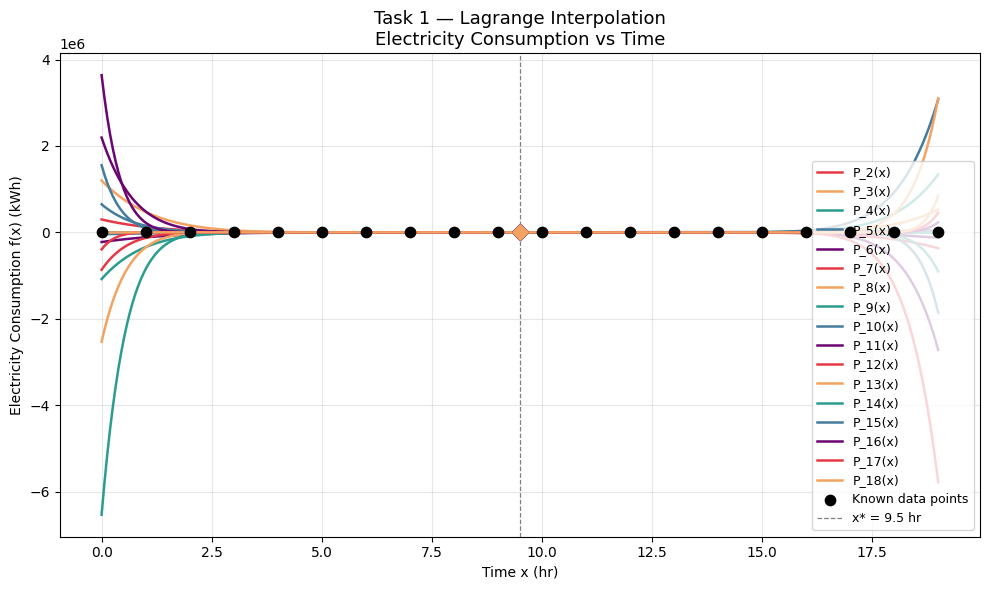

In [38]:
#  TASK 1 — LAGRANGE INTERPOLATION
print("\n")
print("=" * 65)
print("  TASK 1 — LAGRANGE INTERPOLATION")
print("=" * 65)
print(f"  Target: x* = {x_target} hr\n")
print("  Node selection strategy:")
print("  → For each degree k, pick the (k+1) nodes whose x-values")
print("    are closest to x* = 9.5.  Nodes are always sorted by x")
print("    to keep the basis functions well-conditioned.\n")

lagrange_results = []   # (degree, P_k, delta_k)
prev_lagrange = None
max_degree = 19
tolerance = 1e-3
best_degree = None

for degree in range(2, max_degree + 1):
    n_nodes = degree + 1
    xn, yn, idx = get_closest_points(x_points, y_points, x_target, n_nodes)
    P_k, L_vals = lagrange_interpolation(xn, yn, x_target)
    delta_k = abs(P_k - prev_lagrange) if prev_lagrange is not None else None

    print(f"  ── Degree {degree} ─────────────────────────────────")
    print(f"     Nodes (idx): {idx.tolist()}")
    print(f"     x values   : {xn.tolist()}")
    print(f"     y values   : {[f'{v:.3f}' for v in yn]}")
    print()

    for i, (Li, xi, yi) in enumerate(zip(L_vals, xn, yn)):
        print(f"     L_{i}({x_target}) = {Li:+.8f}   "
              f"[node x={xi:.0f}, y={yi:.2f}]")

    # Expanded polynomial coefficients
    poly = lagrange_poly_coeffs(xn, yn)
    coeffs = poly.coeffs
    terms = []
    deg_p = len(coeffs) - 1
    for k_c, c in enumerate(coeffs):
        p = deg_p - k_c
        if p == 0:
            terms.append(f"{c:+.6f}")
        elif p == 1:
            terms.append(f"{c:+.6f}·x")
        else:
            terms.append(f"{c:+.6f}·x^{p}")
    print(f"\n     Expanded P_{degree}(x) = {'  '.join(terms)}")
    print(f"     P_{degree}({x_target}) = {P_k:.8f} kWh")
    if delta_k is not None:
        print(f"     Δ_{degree}            = {delta_k:.4e}")
    print()

    lagrange_results.append((degree, P_k, delta_k))

    if delta_k is not None and delta_k < tolerance:
        best_degree = degree

        print(f"Convergence achieved at degree {degree}")
        print(f"Δ_{degree} = {delta_k:.4e} < tolerance ({tolerance})")
        print()

        break

    prev_lagrange = P_k

# fallback if never converged
if best_degree is None:
    best_degree = degree
    prev_lagrange = P_k

# ── Convergence summary table ──
print("  Convergence Summary — Lagrange")

rows = []

for deg, val, dk in lagrange_results:
    rows.append([
        deg,
        f"{val:.8f}",
        "—" if dk is None else f"{dk:.4e}"
    ])

print(tabulate(
    rows,
    headers=["Degree k", "P_k(9.5) [kWh]", "Δ_k"],
    tablefmt="grid"
))

# ── Lagrange plot ──
fig1, ax1 = plt.subplots(figsize=(10, 6))
x_plot = np.linspace(x_points[0], x_points[-1], 600)
colors = ["#e63946", "#f4a261", "#2a9d8f", "#457b9d", "#6a0572"]

for i, degree in enumerate(range(2, best_degree)):
    n_nodes = degree + 1
    xn, yn, _ = get_closest_points(x_points, y_points, x_target, n_nodes)
    y_curve = [lagrange_interpolation(xn, yn, xi)[0] for xi in x_plot]
    ax1.plot(x_plot, y_curve, color=colors[i % len(colors)], linewidth=1.8,
             label=f"P_{degree}(x)")

    P_k_val = lagrange_interpolation(xn, yn, x_target)[0]
    ax1.scatter([x_target], [P_k_val], color=colors[i % len(colors)], marker="D",
                s=60, zorder=6)

ax1.scatter(x_points, y_points, color="black", zorder=7,
            s=55, label="Known data points")
ax1.axvline(x_target, color="gray", linestyle="--",
            linewidth=0.9, label="x* = 9.5 hr")
ax1.set_title("Task 1 — Lagrange Interpolation\n"
              "Electricity Consumption vs Time", fontsize=13)
ax1.set_xlabel("Time x (hr)")
ax1.set_ylabel("Electricity Consumption f(x) (kWh)")
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



  TASK 2 — NEWTON'S DIVIDED DIFFERENCE INTERPOLATION
  Target: x* = 9.5 hr

  Node ordering strategy:
  → Nodes are sorted by |x_i − x*| (nearest-first).
  → This minimises the leading error term in the Newton
    forward/backward formula and improves convergence.

  Rank   x (hr)       f(x) (kWh)       |x − 9.5|
  -----------------------------------------------
  0      10           851.30           0.5
  1      9            802.70           0.5
  2      11           893.50           1.5
  3      8            768.10           1.5
  4      7            741.60           2.5
  5      12           962.80           2.5
  6      13           1031.40          3.5
  7      6            719.40           3.5
  8      14           1094.60          4.5
  9      5            701.80           4.5
  10     4            684.20           5.5
  11     15           1168.90          5.5
  12     3            639.50           6.5
  13     16           1227.30          6.5
  14     17           1279.50  

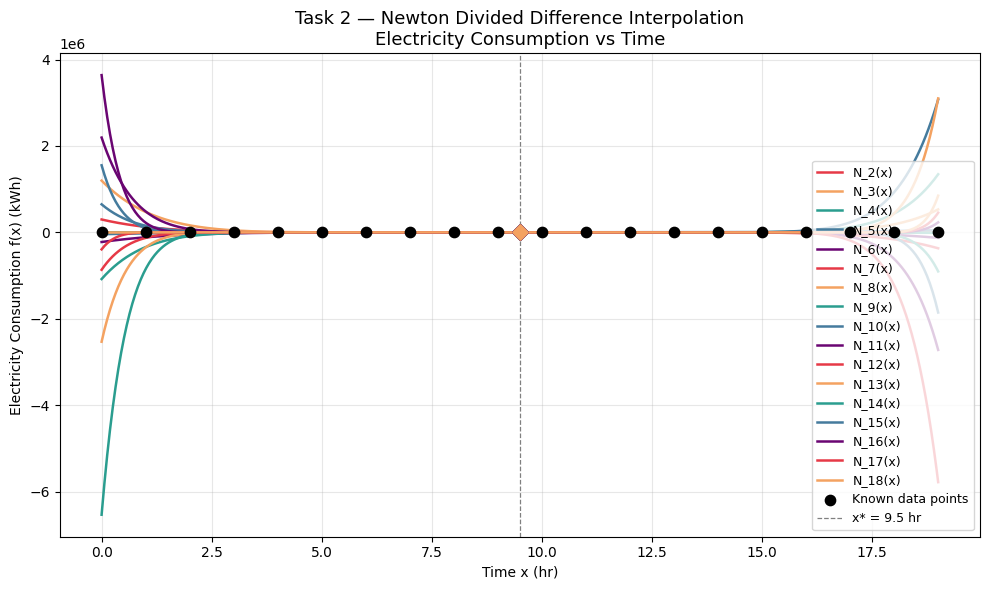

In [39]:
#  TASK 2 — NEWTON'S DIVIDED DIFFERENCE
print("\n")
print("=" * 65)
print("  TASK 2 — NEWTON'S DIVIDED DIFFERENCE INTERPOLATION")
print("=" * 65)
print(f"  Target: x* = {x_target} hr\n")

# Order nodes by proximity to x*
order = np.argsort(np.abs(x_points - x_target))
x_ordered = x_points[order]
y_ordered = y_points[order]

print("  Node ordering strategy:")
print("  → Nodes are sorted by |x_i − x*| (nearest-first).")
print("  → This minimises the leading error term in the Newton")
print("    forward/backward formula and improves convergence.\n")
print(f"  {'Rank':<6} {'x (hr)':<12} {'f(x) (kWh)':<16} {'|x − 9.5|'}")
print("  " + "-" * 47)
for i, (xi, yi) in enumerate(zip(x_ordered, y_ordered)):
    print(f"  {i:<6} {xi:<12.0f} {yi:<16.2f} {abs(xi - x_target):.1f}")

# ── Newton convergence ──
print("\n  Newton Interpolation — Degree-by-Degree Results")
newton_results = []   # (degree, N_k, delta_k)
prev_newton = None
max_degree = 19
tolerance = 1e-3
best_degree_newton = None

for degree in range(2, max_degree + 1):
    n_nodes = degree + 1
    xn = x_ordered[:n_nodes]
    yn = y_ordered[:n_nodes]
    N_k, dd_k = newton_interpolation(xn, yn, x_target)
    delta_k = abs(N_k - prev_newton) if prev_newton is not None else None

    print(f"\n  ── Degree {degree} ─────────────────────────────────")
    print(f"     Nodes x = {xn.tolist()}")
    print(f"     Coefficients (top-row of DD table):")
    for j in range(n_nodes):
        print(f"       c_{j} = f[x_0..x_{j}] = {dd_k[0,j]:.8f}")
    print(f"     N_{degree}({x_target}) = {N_k:.8f} kWh")
    if delta_k is not None:
        print(f"     Δ_{degree}            = {delta_k:.4e}")

    newton_results.append((degree, N_k, delta_k))
    if delta_k is not None and delta_k < tolerance:

        best_degree_newton = degree

        print("\n" + "=" * 65)
        print(f"  Convergence achieved at degree {degree}")
        print(
            f"  Δ_{degree} = {delta_k:.4e} "
            f"< tolerance ({tolerance})"
        )
        print("=" * 65)

        break

    prev_newton = N_k

# fallback if convergence not reached
if best_degree_newton is None:
    best_degree_newton = degree


# ── Final divided-difference table ──

optimal_nodes = best_degree_newton + 1

xn_opt = x_ordered[:optimal_nodes]
yn_opt = y_ordered[:optimal_nodes]

dd_opt = divided_diff_table(xn_opt, yn_opt)

print(f"\n  Final Divided-Difference Table "
      f"({optimal_nodes} nodes)\n")

col_headers = ["x"] + [
    f"f[·]^{k}" for k in range(optimal_nodes)
]

col_headers[1] = "f[x_i]"

table_rows = []

for i in range(optimal_nodes):

    row = [f"{xn_opt[i]:.4f}"]

    for j in range(optimal_nodes):

        if i + j < optimal_nodes:
            row.append(f"{dd_opt[i][j]:.6f}")
        else:
            row.append("")

    table_rows.append(row)

print(tabulate(
    table_rows,
    headers=col_headers,
    tablefmt="grid"
))

# ── Newton convergence table ──
print("\n  Convergence Summary — Newton")
rows = []
for deg, val, dk in newton_results:
    rows.append([deg,
                 f"{val:.8f}",
                 "—" if dk is None else f"{dk:.4e}"
              ])
print(tabulate(rows,
               headers=["Degree k", "N_k(9.5) [kWh]", "Δ_k", "|Error|"],
               tablefmt="grid"))

# ── Newton plot ──
fig2, ax2 = plt.subplots(figsize=(10, 6))

for i, degree in enumerate(range(2, best_degree)):
    n_nodes = degree + 1
    xn = x_ordered[:n_nodes]
    yn = y_ordered[:n_nodes]
    y_curve = [newton_interpolation(xn, yn, xi)[0] for xi in x_plot]
    ax2.plot(x_plot, y_curve, color=colors[i % len(colors)], linewidth=1.8,
             label=f"N_{degree}(x)")

    N_k_val = newton_interpolation(xn, yn, x_target)[0]
    ax2.scatter([x_target], [N_k_val], color=colors[i % len(colors)], marker="D",
                s=60, zorder=6)

ax2.scatter(x_points, y_points, color="black", zorder=7,
            s=55, label="Known data points")
ax2.axvline(x_target, color="gray", linestyle="--",
            linewidth=0.9, label="x* = 9.5 hr")
ax2.set_title("Task 2 — Newton Divided Difference Interpolation\n"
              "Electricity Consumption vs Time", fontsize=13)
ax2.set_xlabel("Time x (hr)")
ax2.set_ylabel("Electricity Consumption f(x) (kWh)")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()